<a href="https://colab.research.google.com/github/ipavlopoulos/ndfu/blob/main/ndfu_synthetic_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning with nDFU on synthetic data

This notebook uses a `UnimodalLearner` class to test a simple idea: examples with pole-like annotator disagreement should not always be forced into the ordinary labels.

This notebook explains that learning setup with synthetic data. We create small numeric features and artificial annotator ratings. The goal is to make the learning logic visible.

## The idea

For every item, the original learner does three things:

1. Convert annotator scores to a histogram with `pdf`.
2. Compute nDFU on that histogram.
3. Build a target label:

`k+1` if `nDFU > threshold`, otherwise use the ordinary majority label.

For toxicity experiments, the ordinary labels are `civil` and `toxic`, so the K+1 learner has three labels: `civil`, `toxic`, and `k+1`. The extra class means: this item has structured disagreement and should be modeled separately.

In [1]:
#@title Setup
try:
    from ndfu import UnimodalLearner, dfu, pdf
except ImportError:
    import sys
    import subprocess

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "git+https://github.com/ipavlopoulos/ndfu.git",
    ])
    from ndfu import UnimodalLearner, dfu, pdf

import os
import tempfile
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Pandas requires version.*")

try:
    get_ipython()
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))
if not IN_NOTEBOOK:
    os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(8)
SCALE = range(1, 6)
FEATURE_COLS = ["x1_toxicity_signal", "x2_disagreement_signal"]


def show_or_close(fig):
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)


## Synthetic annotations

Each item gets two numeric features. The first feature is a simple toxicity signal: negative values tend to be toxic and positive values tend to be civil. The second feature is a disagreement signal: larger values make pole-like annotation patterns more likely.

We create three kinds of annotation distributions:

- `civil`: most ratings are high.
- `toxic`: most ratings are low.
- `polarized`: many annotators choose low ratings and many choose high ratings.

The synthetic data is intentionally a little difficult. Polarized items live in the same feature space as ordinary items, but their binary labels are unstable because a small sampling difference can make the majority look civil or toxic. That makes them noisy supervision for a two-class classifier. K+1 learning gives those examples their own class instead.


In [2]:
#@title Generate synthetic examples
def make_scores(kind, n_annotators=12):
    if kind == "civil":
        return RNG.choice([3, 4, 5], size=n_annotators, p=[0.15, 0.35, 0.50]).tolist()
    if kind == "toxic":
        return RNG.choice([1, 2, 3], size=n_annotators, p=[0.50, 0.35, 0.15]).tolist()
    if kind == "polarized":
        # Mostly low and high ratings. A little middle mass keeps the toy data realistic.
        return RNG.choice([1, 2, 3, 4, 5], size=n_annotators, p=[0.46, 0.02, 0.04, 0.02, 0.46]).tolist()
    raise ValueError(kind)


def make_synthetic_dataset(n=1200):
    rows = []
    for _ in range(n):
        draw = RNG.random()
        if draw < 0.34:
            kind = "civil"
            signal = RNG.normal(0.55, 0.65)
            disagreement_signal = RNG.normal(-0.35, 0.55)
        elif draw < 0.68:
            kind = "toxic"
            signal = RNG.normal(-0.55, 0.65)
            disagreement_signal = RNG.normal(-0.35, 0.55)
        else:
            kind = "polarized"
            signal = RNG.normal(0.00, 0.95)
            disagreement_signal = RNG.normal(1.10, 0.55)

        scores = make_scores(kind)
        features = np.array([
            signal + RNG.normal(scale=0.35),
            disagreement_signal + RNG.normal(scale=0.35),
        ])
        rows.append({"x1_toxicity_signal": features[0], "x2_disagreement_signal": features[1], "kind": kind, "scores": scores})
    return pd.DataFrame(rows)


data = make_synthetic_dataset()
display(data.head())
display(data.kind.value_counts().rename("count").to_frame())


,x1_toxicity_signal,x2_disagreement_signal,kind,scores
0,-0.105195,-1.113545,civil,"[5, 5, 4, 4, 4, 3, 4, 4, 4, 4, 4, 5]"
1,-1.122673,-0.005732,toxic,"[3, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1]"
2,1.503464,0.109441,civil,"[5, 5, 3, 5, 5, 5, 3, 4, 5, 5, 4, 4]"
3,-1.421663,-1.156920,toxic,"[1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1]"
4,0.504799,1.040756,civil,"[5, 5, 4, 4, 4, 4, 4, 4, 5, 5, 4, 4]"


,count
kind,
civil,414
toxic,394
polarized,392


## Visualize the synthetic input space

The two generated features form a deliberately overlapping input space. `x1_toxicity_signal` separates ordinary civil and toxic examples, while `x2_disagreement_signal` makes polarized examples more likely.

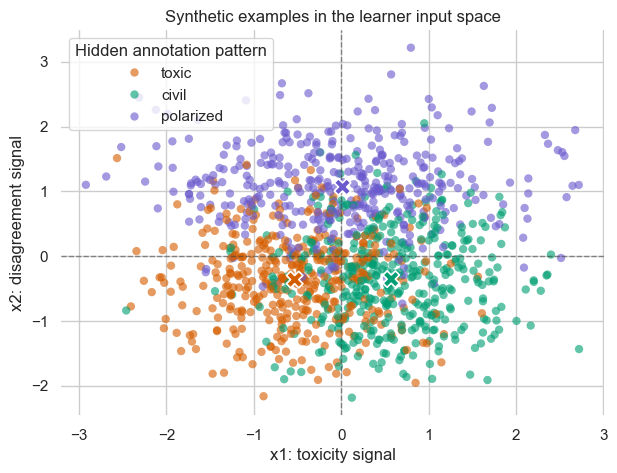

In [3]:
#@title Synthetic input space
kind_order = ["toxic", "civil", "polarized"]
kind_palette = {"toxic": "#d55e00", "civil": "#009e73", "polarized": "#6a5acd"}

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=data,
    x=FEATURE_COLS[0],
    y=FEATURE_COLS[1],
    hue="kind",
    hue_order=kind_order,
    palette=kind_palette,
    alpha=0.62,
    s=36,
    linewidth=0,
    ax=ax,
)

centroids = data.groupby("kind")[FEATURE_COLS].mean().loc[kind_order]
ax.scatter(
    centroids[FEATURE_COLS[0]],
    centroids[FEATURE_COLS[1]],
    marker="X",
    s=140,
    c=[kind_palette[kind] for kind in kind_order],
    edgecolor="white",
    linewidth=1.2,
    zorder=4,
)
ax.axvline(0, color="0.25", linestyle="--", linewidth=1, alpha=0.55)
ax.axhline(0, color="0.25", linestyle="--", linewidth=1, alpha=0.55)
ax.set_title("Synthetic examples in the learner input space")
ax.set_xlabel("x1: toxicity signal")
ax.set_ylabel("x2: disagreement signal")
ax.legend(title="Hidden annotation pattern", frameon=True)
sns.despine(ax=ax, left=True, bottom=True)
show_or_close(fig)


## Import the reusable learner

The package now provides `UnimodalLearner`, a reusable version of the K+1 learning pattern from the application notebook. It keeps the same conceptual parts:

- compute `HIST` and `DFU` for each item,
- derive a binary majority label, here `civil` or `toxic`,
- create a K+1 target where high-nDFU items become `k+1`,
- train a normal binary baseline, a unimodal-only baseline, and a K+1 model.


In [4]:
#@title Use the library learner
# UnimodalLearner is imported from ndfu in the setup cell.
# For a 1-5 scale, the default ordinary label is:
#   toxic if at least half of annotators choose ratings below 3, otherwise civil.
UnimodalLearner


ndfu.learning.UnimodalLearner

## Split the data and inspect nDFU

The synthetic data has a hidden `kind` column only so we can check that nDFU is finding the intended pole-like cases. The learner itself only uses features and annotation scores.

,count,mean,min,max
kind,,,,
civil,248.0,0.025189,0.0,0.666667
polarized,235.0,0.590216,0.0,1.000000
toxic,237.0,0.026639,0.0,0.600000


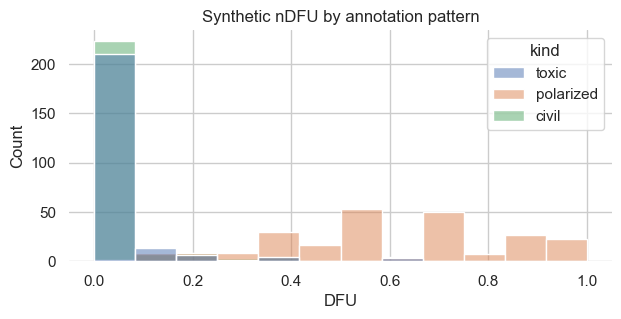

In [5]:
#@title Train/dev/test split and nDFU inspection
train, temp = train_test_split(data, test_size=0.40, random_state=2046, stratify=data.kind)
dev, test = train_test_split(temp, test_size=0.50, random_state=2046, stratify=temp.kind)

learner = UnimodalLearner(
    train,
    dev,
    test,
    feature_cols=FEATURE_COLS,
    scale=SCALE,
    threshold=0.0,
)

summary = learner.train.groupby("kind").DFU.describe()[["count", "mean", "min", "max"]]
display(summary)

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(data=learner.train, x="DFU", hue="kind", bins=12, multiple="layer", ax=ax)
ax.set_title("Synthetic nDFU by annotation pattern")
sns.despine(ax=ax, left=True, bottom=True)
show_or_close(fig)


## How labels change under K+1 learning

The ordinary binary target collapses every item into `civil` or `toxic`. The K+1 target keeps ordinary labels for unimodal items, but sends high-nDFU items to the extra `k+1` class.

In [6]:
#@title Compare binary and K+1 targets
display(pd.crosstab(learner.train.binary_target, learner.train.kplus_target, margins=True))
display(pd.crosstab(learner.train.kind, learner.train.kplus_target, margins=True))


kplus_target,civil,k+1,toxic,All
binary_target,,,,
civil,224,135,0,359
toxic,0,151,210,361
All,224,286,210,720


kplus_target,civil,k+1,toxic,All
kind,,,,
civil,223,25,0,248
polarized,1,234,0,235
toxic,0,27,210,237
All,224,286,210,720


## Train the three models

We train three small logistic-regression models:

- `binary baseline`: learn `civil` vs. `toxic` from all examples.
- `unimodal-only baseline`: discard high-nDFU training examples and learn only from single-peak examples.
- `K+1 model`: learn `civil`, `toxic`, and `k+1` jointly.

In [7]:
#@title Fit models
learner.fit_binary_baseline()
learner.fit_unimodal_only_baseline()
learner.fit_kplus_model()
print(f"Removed {learner.removed_train_size_} high-nDFU training items from {len(learner.train)} total items.")
print("K+1 classes:", list(learner.kplus_model.classes_))


Removed 286 high-nDFU training items from 720 total items.
K+1 classes: ['civil', 'k+1', 'toxic']


## Evaluate K+1 detection

First, evaluate the three-class problem directly. In this synthetic notebook, `k+1` means the model predicts that an item has structured disagreement rather than a clean ordinary label.

In [8]:
#@title Three-class report
kplus_prediction = learner.kplus_model.predict(learner.features(learner.test))
print(classification_report(learner.test.kplus_target, kplus_prediction))

cm = confusion_matrix(learner.test.kplus_target, kplus_prediction, labels=list(learner.kplus_model.classes_))
display(pd.DataFrame(cm, index=learner.kplus_model.classes_, columns=learner.kplus_model.classes_))


              precision    recall  f1-score   support

       civil       0.68      0.65      0.66        77
         k+1       0.70      0.73      0.72        93
       toxic       0.71      0.70      0.71        70

    accuracy                           0.70       240
   macro avg       0.70      0.69      0.69       240
weighted avg       0.70      0.70      0.70       240



,civil,k+1,toxic
civil,50,18,9
k+1,14,68,11
toxic,10,11,49


## Evaluate ordinary labels on unpolarized items

Does the K+1 model still behaves well on ordinary civil/toxic examples? To answer that, we will evaluate on low-nDFU examples and ignore the `k+1` probability when choosing between `civil` and `toxic`.

In this synthetic setup, the binary baseline has seen pole-like examples as if they were ordinary civil/toxic labels. The K+1 model has a separate label for them, so its ordinary civil/toxic boundary can be cleaner.


In [9]:
#@title Binary reports on low-nDFU test examples
ordinary_test = learner.test[learner.test.DFU == 0]
gold = ordinary_test.binary_target

baseline_pred = learner.binary_model.predict(learner.features(ordinary_test))
clean_pred = learner.clean_binary_model.predict(learner.features(ordinary_test))
kplus_binary_pred = learner.binary_predictions_from_kplus(ordinary_test)

rows = []
for name, pred in [
    ("binary baseline", baseline_pred),
    ("unimodal-only baseline", clean_pred),
    ("K+1 model, k+1 ignored", kplus_binary_pred),
]:
    rows.append({"model": name, "macro_f1": f1_score(gold, pred, average="macro")})

display(pd.DataFrame(rows).sort_values("macro_f1", ascending=False))
print("Binary baseline")
print(classification_report(gold, baseline_pred))
print("K+1 model with k+1 probability ignored")
print(classification_report(gold, kplus_binary_pred))


,model,macro_f1
2,"K+1 model, k+1 ignored",0.836364
1,unimodal-only baseline,0.829648
0,binary baseline,0.815473


Binary baseline
              precision    recall  f1-score   support

       civil       0.81      0.84      0.83        77
       toxic       0.82      0.79      0.80        70

    accuracy                           0.82       147
   macro avg       0.82      0.81      0.82       147
weighted avg       0.82      0.82      0.82       147

K+1 model with k+1 probability ignored
              precision    recall  f1-score   support

       civil       0.84      0.84      0.84        77
       toxic       0.83      0.83      0.83        70

    accuracy                           0.84       147
   macro avg       0.84      0.84      0.84       147
weighted avg       0.84      0.84      0.84       147



## The threshold controls how many items become K+1

The original application tries several nDFU thresholds. Lower thresholds send more examples to `k+1`; higher thresholds keep more examples in the ordinary labels.

,threshold,kplus_share
0,0.0,0.397222
1,0.1,0.391667
2,0.2,0.331944
3,0.3,0.311111
4,0.4,0.258333
5,0.5,0.193056
6,0.6,0.150000
7,0.7,0.123611
8,0.8,0.069444
9,0.9,0.031944


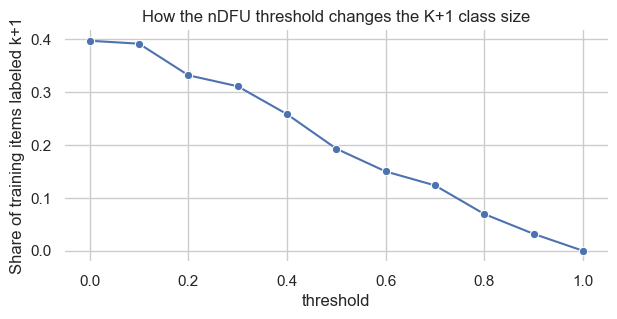

In [10]:
#@title K+1 support by nDFU threshold
thresholds = np.linspace(0, 1, 11)
support = []
for threshold in thresholds:
    labels = learner.train.apply(
        lambda row: "k+1" if row.DFU > threshold else row.binary_target,
        axis=1,
    )
    support.append({"threshold": threshold, "kplus_share": np.mean(labels == "k+1")})

support = pd.DataFrame(support)
display(support)

fig, ax = plt.subplots(figsize=(7, 3))
sns.lineplot(data=support, x="threshold", y="kplus_share", marker="o", ax=ax)
ax.set_title("How the nDFU threshold changes the K+1 class size")
ax.set_ylabel("Share of training items labeled k+1")
sns.despine(ax=ax, left=True, bottom=True)
show_or_close(fig)


## Takeaway

The learner is not just a classifier trick. It encodes a modeling choice: if annotators form poles, the item may represent a different phenomenon than ordinary civil/toxic examples. nDFU supplies the signal for that choice, and K+1 learning gives the model an explicit place to put structured disagreement.